In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sellmeier coefficients for KTP
def n_x_ktp(wavelength):
    """Calculate the refractive index for the x-axis of KTP using the Sellmeier equation."""
    return np.sqrt(3.0065 + 0.0391 / (wavelength**2 - 0.04251) - 0.01327 * wavelength**2)

def n_y_ktp(wavelength):
    """Calculate the refractive index for the y-axis of KTP using the Sellmeier equation."""
    return np.sqrt(3.0333 + 0.04154 / (wavelength**2 - 0.04547) - 0.01408 * wavelength**2)

def n_z_ktp(wavelength):
    """Calculate the refractive index for the z-axis of KTP using the Sellmeier equation."""
    return np.sqrt(3.3134 + 0.05694 / (wavelength**2 - 0.05658) - 0.01682 * wavelength**2)

# nonlinear coefficients for KTP
d_ktp = np.array([[0,0,0,0,1.91],[0,0,0,3.64,0],[2.54,4.35,16.9,0,0]]) # pm/V

def d_eff(phi, theta):
    return (d_ktp[1,3] - d_ktp[0,4]) * np.sin(phi)**2 * np.sin(theta)**2 - (d_ktp[0,4]*np.sin(phi)**2 + d_ktp[1,3]*np.cos(phi)**2)*np.sin(theta)

In [16]:
wl_fund = 0.98 #np.linspace(0.98, 1.1, 100) # microns
wl_shg = wl_fund / 2
n_x_fund = n_x_ktp(wl_fund)
n_y_fund = n_y_ktp(wl_fund)
n_z_fund = n_z_ktp(wl_fund)
n_x_shg = n_x_ktp(wl_shg)
n_y_shg = n_y_ktp(wl_shg)
n_z_shg = n_z_ktp(wl_shg)

k_fund_x = 2 * np.pi * n_x_fund / wl_fund
k_fund_y = 2 * np.pi * n_y_fund / wl_fund
k_fund_z = 2 * np.pi * n_z_fund / wl_fund

k_shg_x = 2 * np.pi * n_x_shg / wl_shg
k_shg_y = 2 * np.pi * n_y_shg / wl_shg
k_shg_z = 2 * np.pi * n_z_shg / wl_shg

Text(0.5, 1.0, 'Phase Mismatch vs. Angle φ in XY Plane')

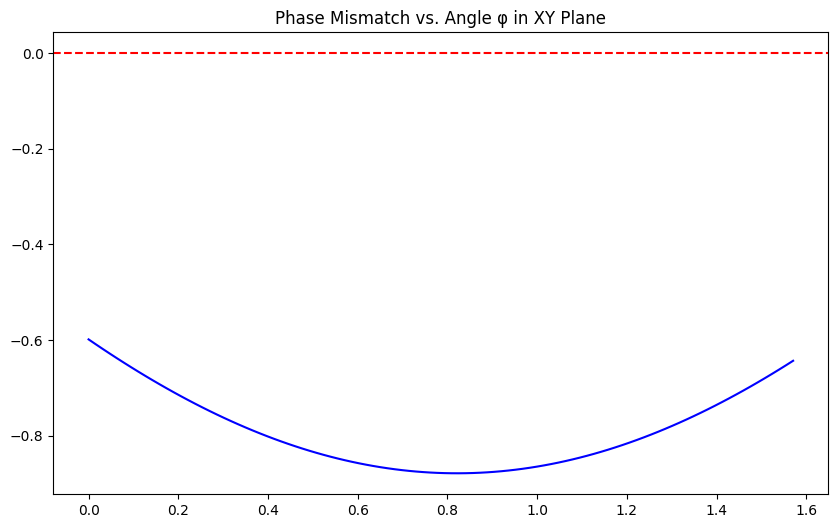

In [18]:
# XY plane
phi = np.linspace(0, np.pi/2, 100)
theta = np.pi/2
k_fund = k_fund_x * np.cos(phi) + k_fund_y * np.sin(phi) + k_fund_z * np.cos(theta)
k_shg = k_shg_x * np.cos(phi) + k_shg_y * np.sin(phi) + k_shg_z * np.cos(theta)
delta_k = 2 * k_fund - k_shg
plt.figure(figsize=(10, 6))
plt.plot(phi, delta_k, label='Phase Mismatch (Δk)', color='blue')
plt.axhline(0, color='red', linestyle='--', label='Phase Matching Condition (Δk=0)')
plt.title('Phase Mismatch vs. Angle φ in XY Plane')